In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.cm as cm

sns.set(style="whitegrid")

In [2]:
file_path = 'train.csv'

df = pd.read_csv(file_path)

cols_to_drop = ['loudness', 'energy']

df = df.drop(columns=cols_to_drop)

In [3]:
y_true = df['Class']
X_raw = df.drop(columns=['Class'])

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols.remove("Class")
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_tr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_tr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_tr, num_cols),
        ('cat', cat_tr, cat_cols)
    ])

X_scaled = preprocessor.fit_transform(X_raw)

if hasattr(X_scaled, 'toarray'):
    X_scaled = X_scaled.toarray()

In [4]:
k_range = range(2, 12)
sil_scores = []
wcss = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    wcss.append(kmeans.inertia_)
    print(f"k={k}: Силуэтный коэффициент = {score:.3f}, WCSS = {kmeans.inertia_:.2f}")

optimal_k = k_range[sil_scores.index(max(sil_scores))]
print(f"\nОптимальное количество кластеров: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f"KMeans создал {len(np.unique(kmeans_labels))} кластеров")
print(f"Размеры кластеров: {np.bincount(kmeans_labels)}")

k=2: Силуэтный коэффициент = 0.085, WCSS = 230846.17
k=3: Силуэтный коэффициент = 0.084, WCSS = 218213.54
k=4: Силуэтный коэффициент = 0.086, WCSS = 204666.58
k=5: Силуэтный коэффициент = 0.083, WCSS = 196054.18
k=6: Силуэтный коэффициент = 0.083, WCSS = 188205.54
k=7: Силуэтный коэффициент = 0.088, WCSS = 182546.67
k=8: Силуэтный коэффициент = 0.083, WCSS = 173042.96
k=9: Силуэтный коэффициент = 0.079, WCSS = 168522.82
k=10: Силуэтный коэффициент = 0.077, WCSS = 164144.73
k=11: Силуэтный коэффициент = 0.076, WCSS = 160086.85

Оптимальное количество кластеров: 7
KMeans создал 7 кластеров
Размеры кластеров: [1696 5314 5123 2915 1050 1135  763]


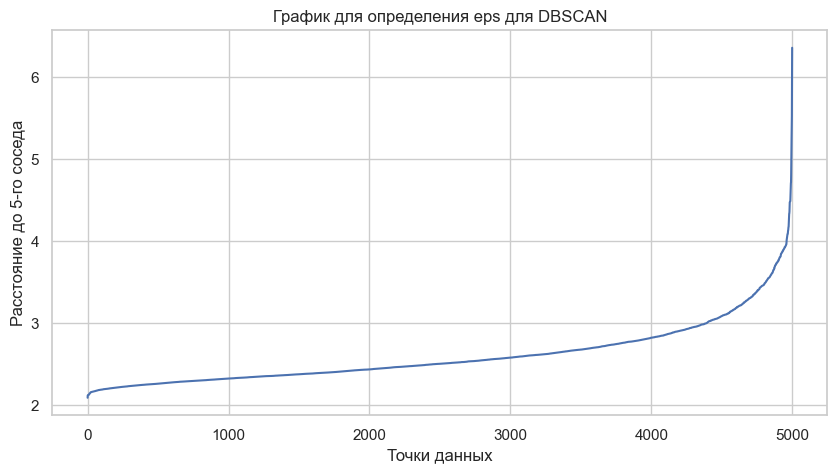

Рекомендуемое значение eps: 3.08
  Создано кластеров: 6
  Шумных точек: 456 (2.5%)
  Размеры кластеров: [16286  1121    85    31    10     7]


In [5]:
n_samples_eps = min(5000, len(X_scaled))
indices = np.random.choice(len(X_scaled), n_samples_eps, replace=False)
X_sample = X_scaled[indices]

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_sample)
distances, _ = neighbors_fit.kneighbors(X_sample)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Точки данных')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('График для определения eps для DBSCAN')
plt.grid(True)
plt.show()

eps_value = np.percentile(distances, 90)
print(f"Рекомендуемое значение eps: {eps_value:.2f}")

dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(np.unique(dbscan_labels[dbscan_labels != -1]))
n_noise = sum(dbscan_labels == -1)

print(f"  Создано кластеров: {n_clusters}")
print(f"  Шумных точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"  Размеры кластеров: {np.bincount(dbscan_labels[dbscan_labels != -1])}")

In [6]:
n_samples_agg = min(3000, len(X_scaled))
indices_agg = np.random.choice(len(X_scaled), n_samples_agg, replace=False)
X_agg_sample = X_scaled[indices_agg]
y_agg_sample = y_true.iloc[indices_agg].values

agg_scores = []
for k in range(2, 10):
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_agg_sample)
    score = silhouette_score(X_agg_sample, labels)
    agg_scores.append(score)
    print(f"k={k}: Силуэтный коэффициент = {score:.3f}")

optimal_agg_k = range(2, 10)[agg_scores.index(max(agg_scores))]
print(f"\nОптимальное количество кластеров: {optimal_agg_k}")

agg = AgglomerativeClustering(n_clusters=optimal_agg_k)
agg_labels_sample = agg.fit_predict(X_agg_sample)

print(f"Agglomerative Clustering создал {len(np.unique(agg_labels_sample))} кластеров")
print(f"Размеры кластеров в подвыборке: {np.bincount(agg_labels_sample)}")

print("\nДля полного набора данных используем KMeans с оптимальным k...")
agg_full = KMeans(n_clusters=optimal_agg_k, random_state=42, n_init='auto')
agg_labels = agg_full.fit_predict(X_scaled)

k=2: Силуэтный коэффициент = 0.104
k=3: Силуэтный коэффициент = 0.102
k=4: Силуэтный коэффициент = 0.106
k=5: Силуэтный коэффициент = 0.107
k=6: Силуэтный коэффициент = 0.077
k=7: Силуэтный коэффициент = 0.082
k=8: Силуэтный коэффициент = 0.084
k=9: Силуэтный коэффициент = 0.065

Оптимальное количество кластеров: 5
Agglomerative Clustering создал 5 кластеров
Размеры кластеров в подвыборке: [1837  431  261  184  287]

Для полного набора данных используем KMeans с оптимальным k...


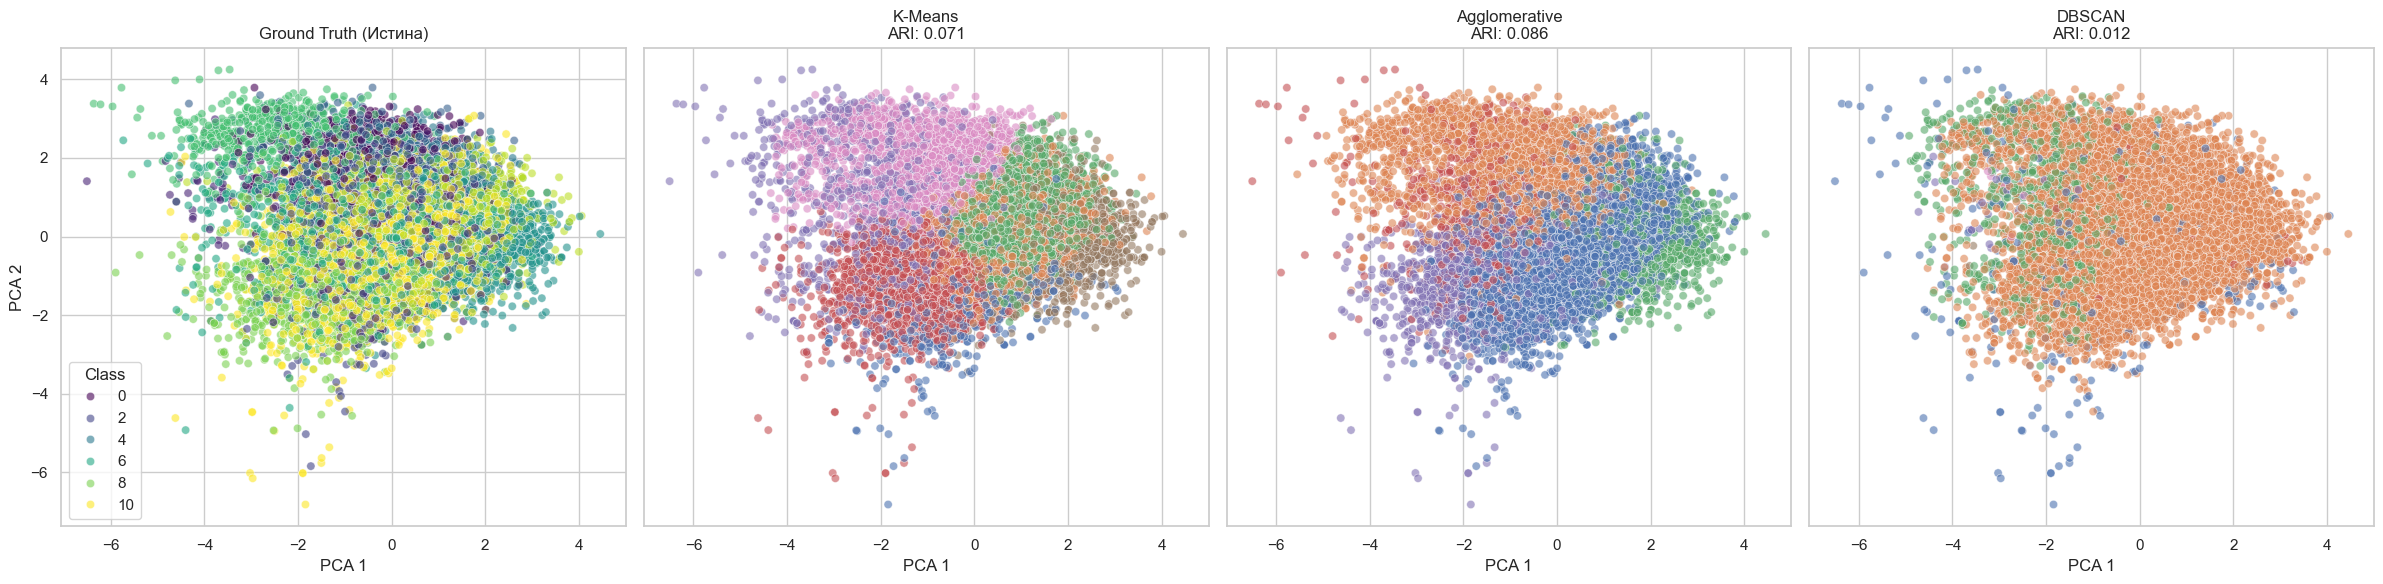

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

models = {
    "K-Means": KMeans(n_clusters=optimal_k, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=optimal_agg_k),
    "DBSCAN": DBSCAN(eps=eps_value, min_samples=5) 
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title("Ground Truth (Истина)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

results = {}

for i, (name, model) in enumerate(models.items(), 1):
    labels = model.fit_predict(X_scaled)
    score = adjusted_rand_score(y_true, labels)
    results[name] = score
    
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='deep', alpha=0.6, ax=axes[i], legend=False)
    axes[i].set_title(f"{name}\nARI: {score:.3f}")
    axes[i].set_xlabel("PCA 1")
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

  Adjusted Rand Index (ARI): 0.086
  Normalized Mutual Info (NMI): 0.157
  Количество кластеров: 7
  Размеры кластеров: [1696 5314 5123 2915 1050 1135  763]
  Шумные точки: 456 (2.5%)
  Adjusted Rand Index (ARI): 0.008
  Normalized Mutual Info (NMI): 0.013
  Количество кластеров: 6
  Размеры кластеров: [16286  1121    85    31    10     7]
  Adjusted Rand Index (ARI): 0.085
  Normalized Mutual Info (NMI): 0.142
  Количество кластеров: 5
  Размеры кластеров: [1842 5992 5883 3020 1259]

Лучший метод по силуэтному коэффициенту: DBSCAN (0.135)


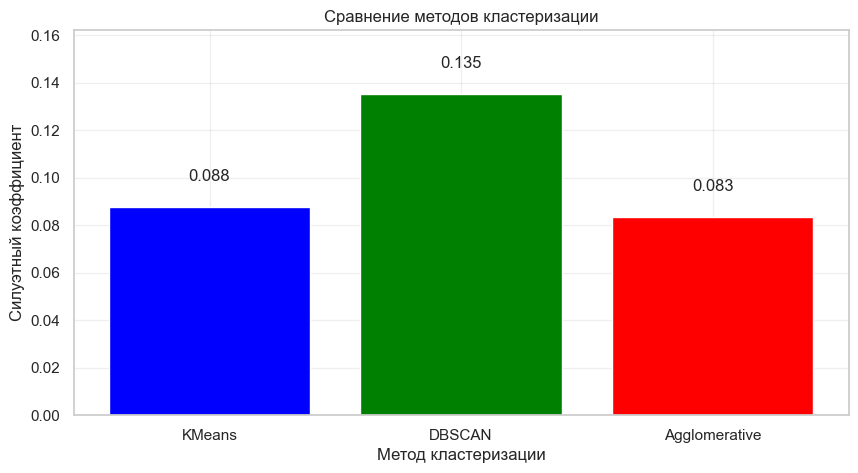

In [8]:
def evaluate_method(name, true_labels, pred_labels, X_data):
    """Оценка метода кластеризации"""

    if name == "DBSCAN":
        mask = pred_labels != -1
        if sum(mask) == 0:
            print("  Все точки отнесены к шуму")
            return None
        print(f"  Шумные точки: {sum(~mask)} ({sum(~mask)/len(pred_labels)*100:.1f}%)")
        pred_labels_filtered = pred_labels[mask]
        true_labels_filtered = true_labels[mask] if hasattr(true_labels, '__len__') else true_labels[mask]
        X_filtered = X_data[mask]
    else:
        mask = slice(None)
        pred_labels_filtered = pred_labels
        true_labels_filtered = true_labels
        X_filtered = X_data

    n_clusters = len(np.unique(pred_labels_filtered))
    sil = silhouette_score(X_filtered, pred_labels_filtered)
    
    ari = adjusted_rand_score(true_labels_filtered, pred_labels_filtered)
    print(f"  Adjusted Rand Index (ARI): {ari:.3f}")
    
    nmi = normalized_mutual_info_score(true_labels_filtered, pred_labels_filtered)
    print(f"  Normalized Mutual Info (NMI): {nmi:.3f}")

    print(f"  Количество кластеров: {n_clusters}")
    print(f"  Размеры кластеров: {np.bincount(pred_labels_filtered)}")

    return sil

kmeans_sil = evaluate_method("KMeans", y_true.values, kmeans_labels, X_scaled)
dbscan_sil = evaluate_method("DBSCAN", y_true.values, dbscan_labels, X_scaled)
agg_sil = evaluate_method("Agglomerative", y_true.values, agg_labels, X_scaled)

scores = {}
if kmeans_sil is not None:
    scores['KMeans'] = kmeans_sil
if dbscan_sil is not None:
    scores['DBSCAN'] = dbscan_sil
if agg_sil is not None:
    scores['Agglomerative'] = agg_sil

best_method = max(scores, key=scores.get)
print(f"\nЛучший метод по силуэтному коэффициенту: {best_method} ({scores[best_method]:.3f})")

plt.figure(figsize=(10, 5))
methods = list(scores.keys())
values = [scores[m] for m in methods]

bars = plt.bar(methods, values, color=['blue', 'green', 'red'])
plt.xlabel('Метод кластеризации')
plt.ylabel('Силуэтный коэффициент')
plt.title('Сравнение методов кластеризации')
plt.ylim(0, max(values) * 1.2)

# Добавляем значения на столбцы
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.show()


# Вывод

Наилучший результат по величине Силуэтного коэффициента показали DBSCAN и KMeans. Но как можно было увидеть в визуализации методов "--- границы кластеров не естествены(не строгие). Для их эффективного различения потребуется учитель.